# 03c — Six-Basis Cyclone Decomposition (Track 109, 1000 hPa)

Applies the six-basis PV tendency projection to an **extratropical cyclone**
tracked by TempestExtremes (SLP-based).

- Track 109 from the **Boston XTC catalogue** (Oct 23–27, 1990)
- PV decomposition at **1000 hPa** for best alignment with SLP tracks
- Uses ``mask="> 0"`` to isolate the cyclone's *positive* PV anomaly
- Basis built from **dh = 0 fields only** (no temporal interpolation)
- Symmetric ±15-grid (±22.5°) patch

Sections mirror ``03_six_basis_projection.ipynb`` (blocking demo):
sample basis visualisation, 2-D component maps, lifecycle time curves,
Cartopy track comparison, animated GIF, and budget closure.


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPImage
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pvtend import (compute_orthogonal_basis, project_field, R_EARTH)
from pvtend.plotting import plot_coefficient_curves
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.decomposition.basis import (PRENORM_PHI1, PRENORM_PHI2,
                                         PRENORM_PHI3, PRENORM_PHI4,
                                         PRENORM_PHI5, PRENORM_PHI6)
from pvtend.derivatives import ddx, ddy, ddp
from pvtend.constants import DEFAULT_LEVELS

# ── Constants / Configuration ──────────────────────
LEVEL_PA   = 1000.0          # hPa
SMOOTH_DEG = 3.0             # Gaussian smoothing half-width (degrees)
GRID_DEG   = 1.5             # ERA5 grid spacing (degrees)

# Symmetric ±10 grid-point half-width → ±15° patch (21 × 21)
HALF_IDX   = 10

# PV mask specification for basis construction
MASK_SPEC  = "> 2e-7"  # SI units, PVU; negative PV anomaly = blocking ridge

ERA_DIR  = "/net/flood/data2/users/x_yan/era"
CLIM_DIR = "/net/flood/data2/users/x_yan/era/clim"
CSV_PATH = "/net/flood/data2/users/x_yan/pvtend/docs/_static/ERA5_TempestExtremes_XTC_Boston.csv"
GIF_PATH = "/net/flood/data2/users/x_yan/pvtend/docs/_static/boston_c_lifecycle_demo.gif"

MONTH_NAMES = {1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",
               7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}


In [2]:
# ── Load CSV and extract Track 109 ──────────────
df_all = pd.read_csv(CSV_PATH)
df = df_all[df_all["track_id_local"] == 109].reset_index(drop=True)

# Build datetime array
df["time"] = pd.to_datetime(
    df[["year","month","day","hour"]].assign(minute=0, second=0)
)
times = df["time"].values

# Convert lon from [0,360) -> [-180,180) to match ERA5
lons_csv = df["lon"].values.copy()
lons_csv[lons_csv > 180] -= 360.0
lats_csv = df["lat"].values.copy()

# Tracked speed via centred differences (m/s)
cos_lat = np.cos(np.radians(lats_csv))
dlat = np.gradient(lats_csv)                        # deg / hour
dlon = np.gradient(lons_csv)                        # deg / hour
vx_track = dlon * (np.pi / 180.0) * R_EARTH * cos_lat / 3600.0  # m/s
vy_track = dlat * (np.pi / 180.0) * R_EARTH / 3600.0            # m/s

N = len(df)
print(f"Track 109: {N} hourly points")
print(f"  Period : {df['time'].iloc[0]} -> {df['time'].iloc[-1]}")
print(f"  Lat    : {lats_csv.min():.1f} deg  - {lats_csv.max():.1f} deg")
print(f"  Lon    : {lons_csv.min():.1f} deg  - {lons_csv.max():.1f} deg")
print(f"  <vx>   : {vx_track.mean():.1f} m/s")
print(f"  <vy>   : {vy_track.mean():.1f} m/s")

Track 109: 96 hourly points
  Period : 1990-10-23 04:00:00 -> 1990-10-27 10:00:00
  Lat    : 34.8 deg  - 53.5 deg
  Lon    : -80.8 deg  - -16.8 deg
  <vx>   : 13.6 m/s
  <vy>   : 5.7 m/s


## 1  ERA5 data-loading helpers

In [3]:
# Caches to avoid re-opening files every timestep
_ds_cache = {}

def _open_era(var, year, month):
    key = (var, year, month)
    if key not in _ds_cache:
        path = f"{ERA_DIR}/era5_{var}_{year}_{month:02d}.nc"
        _ds_cache[key] = xr.open_dataset(path)
    return _ds_cache[key]

def _open_clim(var, month):
    key = ("clim", var, month)
    if key not in _ds_cache:
        mname = MONTH_NAMES[month]
        path = f"{CLIM_DIR}/era5_hourly_clim_1990-2020_{mname}_{var}.nc"
        _ds_cache[key] = xr.open_dataset(path)
    return _ds_cache[key]

def load_era5_field(var, dt64, level_hpa=LEVEL_PA):
    """Load a single 2-D field (lat, lon) from monthly ERA5 file."""
    ts = pd.Timestamp(dt64)
    ds = _open_era(var, ts.year, ts.month)
    da = ds[var].sel(valid_time=str(ts), pressure_level=level_hpa)
    return da.values, ds.latitude.values, ds.longitude.values

def load_clim_field(var, month, day, hour, level_hpa=LEVEL_PA):
    """Load climatological field (lat, lon) matching month/day/hour."""
    dc = _open_clim(var, month)
    da = dc[var].sel(month=month, day=day, hour=hour,
                     pressure_level=level_hpa)
    return da.values

def extract_patch(field2d, lat1d, lon1d, clat, clon, half_idx=HALF_IDX):
    """Extract a symmetric ±half_idx patch around (clat, clon)."""
    ilat = int(np.abs(lat1d - clat).argmin())
    ilon = int(np.abs(lon1d - clon).argmin())

    lat_desc = lat1d[0] > lat1d[-1]
    if lat_desc:
        lat_asc = lat1d[::-1]
        field_asc = field2d[::-1]
        ilat_asc = len(lat1d) - 1 - ilat
    else:
        lat_asc = lat1d
        field_asc = field2d
        ilat_asc = ilat

    i0_lat = ilat_asc - half_idx
    i1_lat = ilat_asc + half_idx + 1
    i0_lon = ilon - half_idx
    i1_lon = ilon + half_idx + 1

    lat_sub = lat_asc[i0_lat:i1_lat]
    lon_sub = lon1d[i0_lon:i1_lon]
    patch = field_asc[i0_lat:i1_lat, i0_lon:i1_lon]

    x_rel = lon_sub - clon
    y_rel = lat_sub - clat
    return patch, x_rel, y_rel, lat_sub, lon_sub

def compute_gradients(pv_patch, lat_sub, x_rel, y_rel):
    """Compute zonal/meridional PV gradients on a patch in SI."""
    dy = np.abs(y_rel[1] - y_rel[0]) * (np.pi / 180.0) * R_EARTH
    dx_arr = (np.abs(x_rel[1] - x_rel[0]) * (np.pi / 180.0)
              * R_EARTH * np.cos(np.radians(lat_sub)))
    pv_dx = ddx(pv_patch, dx_arr, periodic=False)
    pv_dy = ddy(pv_patch, dy)
    return pv_dx, pv_dy

print(f"Helpers defined.  Patch shape = ({2*HALF_IDX+1}, {2*HALF_IDX+1})")


Helpers defined.  Patch shape = (21, 21)


## 2  Sample timestep — basis construction (dh = 0)


In [4]:
# Pick a sample timestep near the middle of the track
SAMPLE_IDX = N // 2
t_s = times[SAMPLE_IDX]
ts_s = pd.Timestamp(t_s)
clat_s = lats_csv[SAMPLE_IDX]
clon_s = lons_csv[SAMPLE_IDX]

print(f"Sample timestep #{SAMPLE_IDX}: {ts_s}  centre = ({clat_s:.1f} N, {clon_s:.1f} E)")

# Load PV at t-1h, t, t+1h (for centred-difference tendency)
pv_m, lat1d, lon1d = load_era5_field("pv", t_s - np.timedelta64(1, "h"))
pv_0, _, _          = load_era5_field("pv", t_s)
pv_p, _, _          = load_era5_field("pv", t_s + np.timedelta64(1, "h"))

# Climatology
pv_bar_0 = load_clim_field("pv", ts_s.month, ts_s.day, ts_s.hour)

# Extract patches — all centred on t's tracked position (dh = 0)
pv_0_p, x_rel, y_rel, lat_sub, lon_sub = extract_patch(pv_0, lat1d, lon1d, clat_s, clon_s)
pv_m_p, _, _, _, _ = extract_patch(pv_m, lat1d, lon1d, clat_s, clon_s)
pv_p_p, _, _, _, _ = extract_patch(pv_p, lat1d, lon1d, clat_s, clon_s)
bar_0_p, *_ = extract_patch(pv_bar_0, lat1d, lon1d, clat_s, clon_s)

# PV anomaly at dh = 0
pv_anom_0 = pv_0_p - bar_0_p

# Centred finite-difference tendency [PVU/s]
from pvtend import ddt
pv_stack = np.stack([pv_m_p, pv_0_p, pv_p_p], axis=0)
pv_dt_raw = ddt(pv_stack, dt_s=3600.0)[1]

# Gradients at dh = 0
pv_dx_0, pv_dy_0 = compute_gradients(pv_anom_0, lat_sub, x_rel, y_rel)

X_rel, Y_rel = np.meshgrid(x_rel, y_rel)

print(f"  Patch shape : {pv_0_p.shape}")
print(f"  PV anom max  : {pv_anom_0.max():.3e} PVU")
print(f"  PV anom min  : {pv_anom_0.min():.3e} PVU")


Sample timestep #48: 1990-10-25 08:00:00  centre = (49.2 N, -60.5 E)


  Patch shape : (21, 21)
  PV anom max  : 4.476e-05 PVU
  PV anom min  : -8.146e-06 PVU


In [5]:
# Build basis from dh = 0 fields
basis = compute_orthogonal_basis(
    pv_anom=pv_anom_0,
    pv_dx=pv_dx_0,
    pv_dy=pv_dy_0,
    x_rel=x_rel,
    y_rel=y_rel,
    mask=MASK_SPEC,
    apply_smoothing=True,
    smoothing_deg=SMOOTH_DEG,
    grid_spacing=GRID_DEG,
)
print("Basis norms :", {k: f"{v:.4e}" for k, v in basis.norms.items()})
print("Scale factors:", basis.scale_factors)
print(f"Mask pixels  : {basis.mask.sum()} / {basis.mask.size}")


Basis norms : {'beta': '8.1965e+01', 'ax': '1.2269e+03', 'ay': '5.1151e+02', 'gamma': '5.7262e+03'}
Scale factors: {'beta': 1000000.0, 'ax': 1000000000000.0, 'ay': 1000000000000.0, 'gamma': 1e+18}
Mask pixels  : 41 / 441


## 3  Visualise the six basis fields

In [ ]:
# 6-basis visualisation with basis.mask contour
from matplotlib.colors import TwoSlopeNorm

fields_b = [basis.phi_int, basis.phi_dx, basis.phi_dy,
            basis.phi_def, basis.phi_strain, basis.phi_lap]
titles_b = [
    r"$\Phi_1$: PV anomaly $q'$",
    r"$\Phi_2$: $\partial q / \partial x$",
    r"$\Phi_3$: $\partial q / \partial y$",
    r"$\Phi_4$: $\partial^2 q / \partial x \partial y$",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 12))

for ax, fld, ttl in zip(axes.flat, fields_b, titles_b):
    # Colour range from mask interior only
    vmax_c = np.nanpercentile(np.abs(fld[basis.mask]), 95)
    if vmax_c < 1e-30:
        vmax_c = 1.0
    norm = TwoSlopeNorm(vmin=-vmax_c, vcenter=0.0, vmax=vmax_c)
    im = ax.imshow(
        fld, origin="lower", cmap="coolwarm", norm=norm,
        extent=[x_rel.min(), x_rel.max(), y_rel.min(), y_rel.max()],
        aspect="equal",
    )
    # Central-blob contour from basis.mask
    ax.contour(X_rel, Y_rel, basis.mask.astype(float), levels=[0.5],
               colors="k", linewidths=1.2, linestyles="--")
    ax.set_title(ttl, fontsize=11)
    ax.set_xlabel("Δlon (deg)")
    ax.set_ylabel("Δlat (deg)")
    plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)

fig.suptitle("Orthogonal bases (cyclone, 1000 hPa)\n"
             "dashed = basis.mask central contour",
             fontsize=13, y=1.04)
fig.tight_layout()
plt.show()


## 4  Project PV tendency onto basis

In [ ]:
pv_dt_smooth = gaussian_smooth_nan(pv_dt_raw, smoothing_deg=SMOOTH_DEG,
                                    grid_spacing=GRID_DEG)
proj = project_field(pv_dt_smooth, basis)

print(f"beta (intensification)    = {proj['beta']:.3e}  s-1")
print(f"ax   (zonal propagation)  = {proj['ax']:.3f}  m/s")
print(f"ay   (merid. propagation) = {proj['ay']:.3f}  m/s")
print(f"gamma1 (shear def.)       = {proj['gamma1']:.3e}  m2 s-1")
print(f"gamma2 (strain def.)      = {proj['gamma2']:.3e}  m2 s-1")
print(f"sigma  (Laplacian)        = {proj['sigma']:.3e}  m2 s-1")
print(f"RMSE / max|dq/dt|         = {proj['rmse'] / (np.nanmax(np.abs(pv_dt_smooth)) + 1e-30):.3f}")

## 5  2-D component maps

In [ ]:
# Reconstruct individual components
beta_comp  = proj["beta_raw"]  * basis.phi_int
ax_comp    = -proj["ax_raw"]   * basis.phi_dx
ay_comp    = -proj["ay_raw"]   * basis.phi_dy
gamma1_comp = -proj["gamma1_raw"] * basis.phi_def
gamma2_comp = -proj["gamma2_raw"] * basis.phi_strain
sigma_comp  = proj["sigma_raw"]  * basis.phi_lap

_m = basis.mask
vmax_prop = max(np.nanpercentile(np.abs(ax_comp[_m]), 95),
                np.nanpercentile(np.abs(ay_comp[_m]), 95))
vmax_id   = max(np.nanpercentile(np.abs(beta_comp[_m]), 95),
                np.nanpercentile(np.abs(gamma1_comp[_m]), 95))
levels_prop = np.linspace(-vmax_prop, vmax_prop, 20)
levels_id   = np.linspace(-vmax_id,   vmax_id,   20)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (comp, title) in enumerate([
    (ax_comp,  "Zonal prop. (−αx·Φ₂)"),
    (ay_comp,  "Merid. prop. (−αy·Φ₃)"),
]):
    a = axes[0, i]
    cf_prop = a.contourf(x_rel, y_rel, comp, levels=levels_prop,
                         cmap="coolwarm", extend="both")
    a.contour(X_rel, Y_rel, basis.mask.astype(float), levels=[0.5],
              colors="k", linewidths=1.0)
    a.set_title(title)
    a.set_aspect("equal")
fig.colorbar(cf_prop, ax=axes[0, :].tolist(), shrink=0.8, label="PVU / s")

for i, (comp, title) in enumerate([
    (beta_comp,  "Intensification (β·Φ₁)"),
    (gamma1_comp, "Shear def. (−γ₁·Φ₄)"),
    (gamma2_comp, "Strain def. (−γ₂·Φ₅)"),
    (sigma_comp,  "Laplacian (σ·Φ₆)"),
]):
    a = axes[1, i]
    cf_id = a.contourf(x_rel, y_rel, comp, levels=levels_id,
                       cmap="coolwarm", extend="both")
    a.contour(X_rel, Y_rel, basis.mask.astype(float), levels=[0.5],
              colors="k", linewidths=1.0)
    a.set_title(title)
    a.set_aspect("equal")
fig.colorbar(cf_id, ax=axes[1, :].tolist(), shrink=0.8, label="PVU / s")

subtitle = (
    f"β = {proj['beta']:.2e} s⁻¹,  "
    f"αx = {proj['ax']:.2f} m/s,  "
    f"αy = {proj['ay']:.2f} m/s,  "
    f"γ₁ = {proj['gamma1']:.2e},  γ₂ = {proj['gamma2']:.2e},  σ = {proj['sigma']:.2e} m² s⁻¹"
)
fig.suptitle(f"PV tendency decomposition — sample #{SAMPLE_IDX} (1000 hPa)\n" + subtitle,
             y=1.04, fontsize=12)
plt.show()


## 5b  Original vs. Reconstructed PV tendency

Level: 1000.0 hPa — single-level PV decomposition

Reconstruction quality:
  RMSE              = 5.257e-11
  RMSE / max|dq/dt| = 0.158
  Correlation       = -0.0149


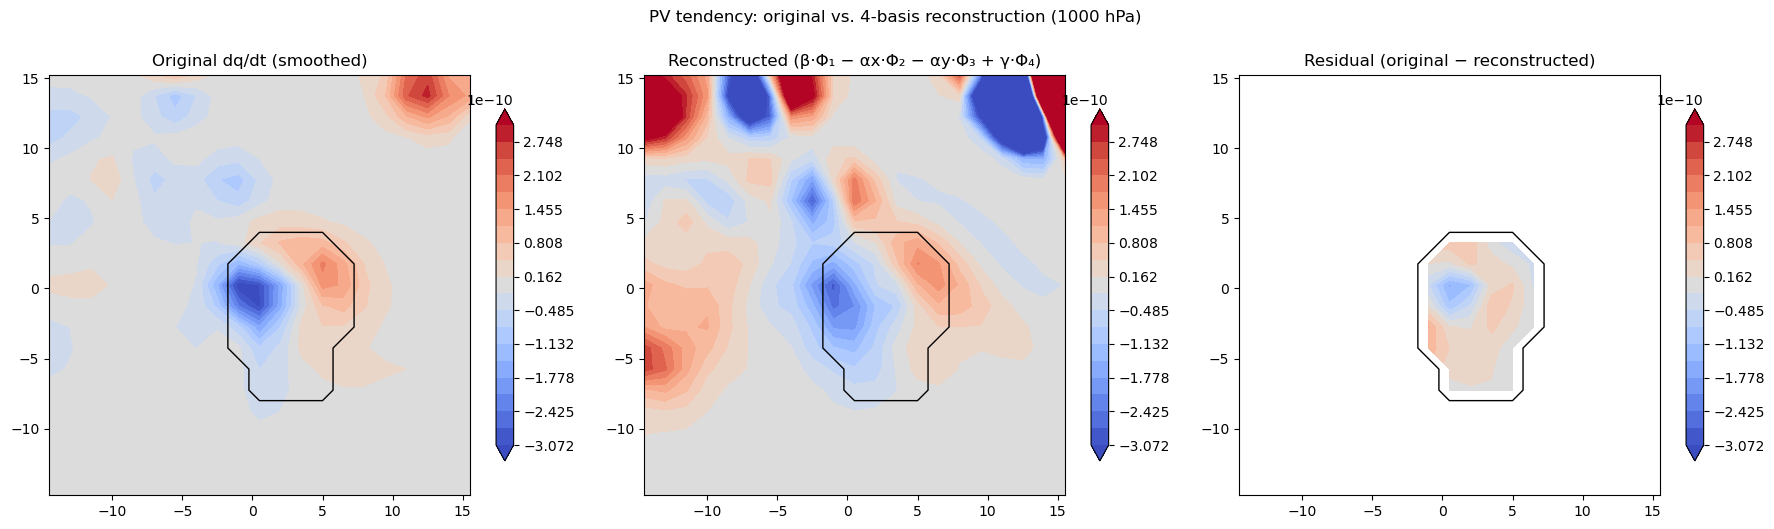

In [9]:
recon = proj["recon"]
resid = proj["resid"]

vmax = np.nanpercentile(np.abs(pv_dt_smooth[basis.mask]), 95)
levels_cf = np.linspace(-vmax, vmax, 20)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cf0 = axes[0].contourf(x_rel, y_rel, pv_dt_smooth,
                        levels=levels_cf, cmap="coolwarm", extend="both")
axes[0].contour(X_rel, Y_rel, basis.mask.astype(float), levels=[0.5],
                colors="k", linewidths=1.0)
axes[0].set_title("Original dq/dt (smoothed)")
axes[0].set_aspect("equal")
plt.colorbar(cf0, ax=axes[0], shrink=0.8)

cf1 = axes[1].contourf(x_rel, y_rel, recon,
                        levels=levels_cf, cmap="coolwarm", extend="both")
axes[1].contour(X_rel, Y_rel, basis.mask.astype(float), levels=[0.5],
                colors="k", linewidths=1.0)
axes[1].set_title("Reconstructed (β·Φ₁ − αx·Φ₂ − αy·Φ₃ + γ·Φ₄)")
axes[1].set_aspect("equal")
plt.colorbar(cf1, ax=axes[1], shrink=0.8)

cf2 = axes[2].contourf(x_rel, y_rel, resid,
                        levels=levels_cf, cmap="coolwarm", extend="both")
axes[2].contour(X_rel, Y_rel, basis.mask.astype(float), levels=[0.5],
                colors="k", linewidths=1.0)
axes[2].set_title("Residual (original − reconstructed)")
axes[2].set_aspect("equal")
plt.colorbar(cf2, ax=axes[2], shrink=0.8)

print(f"Level: {LEVEL_PA} hPa — single-level PV decomposition")
print(f"\nReconstruction quality:")
print(f"  RMSE              = {proj['rmse']:.3e}")
print(f"  RMSE / max|dq/dt| = {proj['rmse'] / (np.nanmax(np.abs(pv_dt_smooth)) + 1e-30):.3f}")
valid = np.isfinite(pv_dt_smooth) & np.isfinite(recon)
if valid.sum() > 2:
    print(f"  Correlation       = {np.corrcoef(pv_dt_smooth[valid], recon[valid])[0,1]:.4f}")

fig.suptitle("PV tendency: original vs. 6-basis reconstruction (1000 hPa)", y=1.02)
fig.tight_layout()
plt.show()


## 6  Lifecycle time curves (full track)

In [ ]:
# Loop over all valid timesteps (skip first & last for centred diff)
coefs = {k: [] for k in ["beta", "ax", "ay", "gamma1", "gamma2", "sigma"]}
valid_idx = list(range(1, N - 1))
n_skipped = 0

for count, ti in enumerate(valid_idx):
    t_i   = times[ti]
    ts_i  = pd.Timestamp(t_i)
    clat_i = lats_csv[ti]
    clon_i = lons_csv[ti]

    # Load PV at t-1h, t, t+1h — all centred on t's tracked position
    pv_m_2d, lat1d, lon1d = load_era5_field("pv", t_i - np.timedelta64(1, "h"))
    pv_0_2d, _, _         = load_era5_field("pv", t_i)
    pv_p_2d, _, _         = load_era5_field("pv", t_i + np.timedelta64(1, "h"))

    # Climatology at t
    pv_bar_0 = load_clim_field("pv", ts_i.month, ts_i.day, ts_i.hour)

    # Extract patches on t's centre (dh = 0)
    pv_0_pa, xr_, yr_, lat_s, lon_s = extract_patch(pv_0_2d, lat1d, lon1d, clat_i, clon_i)
    pv_m_pa, _, _, _, _ = extract_patch(pv_m_2d, lat1d, lon1d, clat_i, clon_i)
    pv_p_pa, _, _, _, _ = extract_patch(pv_p_2d, lat1d, lon1d, clat_i, clon_i)
    bar_0_pa, *_ = extract_patch(pv_bar_0, lat1d, lon1d, clat_i, clon_i)

    anom_0 = pv_0_pa - bar_0_pa

    # Gradients at dh = 0
    dx_0, dy_0 = compute_gradients(anom_0, lat_s, xr_, yr_)

    # Tendency via centred diff
    pv_stack = np.stack([pv_m_pa, pv_0_pa, pv_p_pa], axis=0)
    dt_raw = ddt(pv_stack, dt_s=3600.0)[1]

    # Build basis from dh = 0 fields
    b = compute_orthogonal_basis(
        anom_0, dx_0, dy_0,
        xr_, yr_, mask=MASK_SPEC,
        apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG,
    )

    # ── Guard: skip if Gram-Schmidt produced degenerate basis ──
    _MIN_NORM = 1e-6
    if b.norms is None or any(b.norms[k] < _MIN_NORM for k in ["beta","ax","ay","gamma1","gamma2","sigma"]):
        for k in coefs:
            coefs[k].append(np.nan)
        n_skipped += 1
        continue
    # Project smoothed tendency
    dt_sm = gaussian_smooth_nan(dt_raw, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG)
    p = project_field(dt_sm, b)

    for k in coefs:
        coefs[k].append(p[k])

    if count % 20 == 0:
        print(f"  [{count+1}/{len(valid_idx)}]  {ts_i}  ax={p['ax']:.1f} m/s")

# Convert to arrays
for k in coefs:
    coefs[k] = np.array(coefs[k])

print(f"\nDone — {len(valid_idx)} timesteps, {n_skipped} skipped (degenerate basis).")


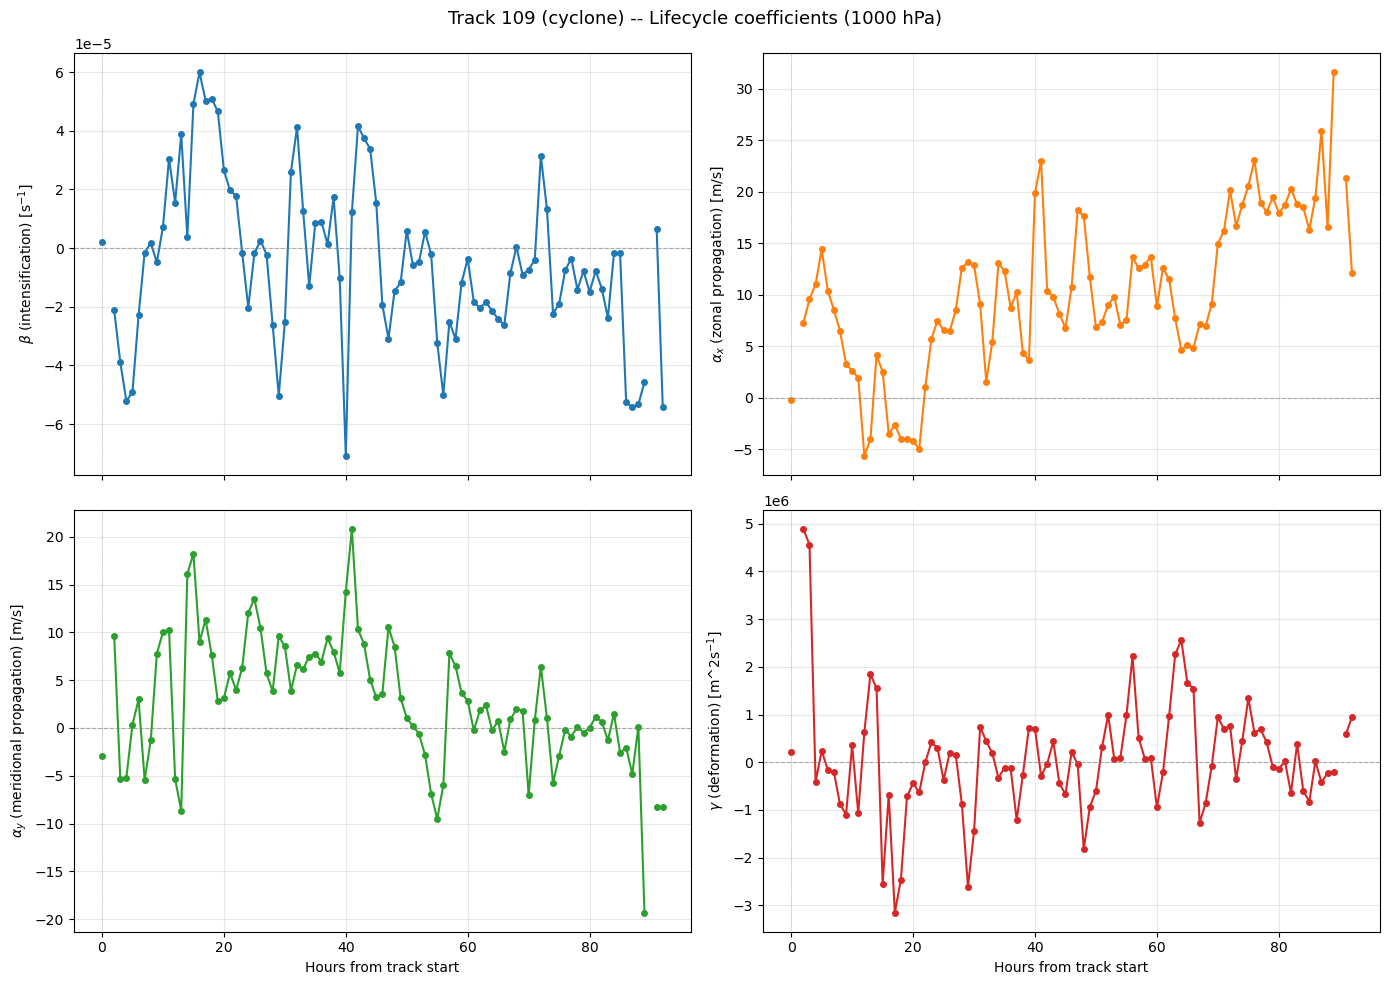

In [11]:
hours = np.arange(len(valid_idx))
fig = plot_coefficient_curves(
    hours,
    coefs,
    title="Track 109 (cyclone) -- Lifecycle coefficients (1000 hPa)",
    xlabel="Hours from track start",
)
plt.show()

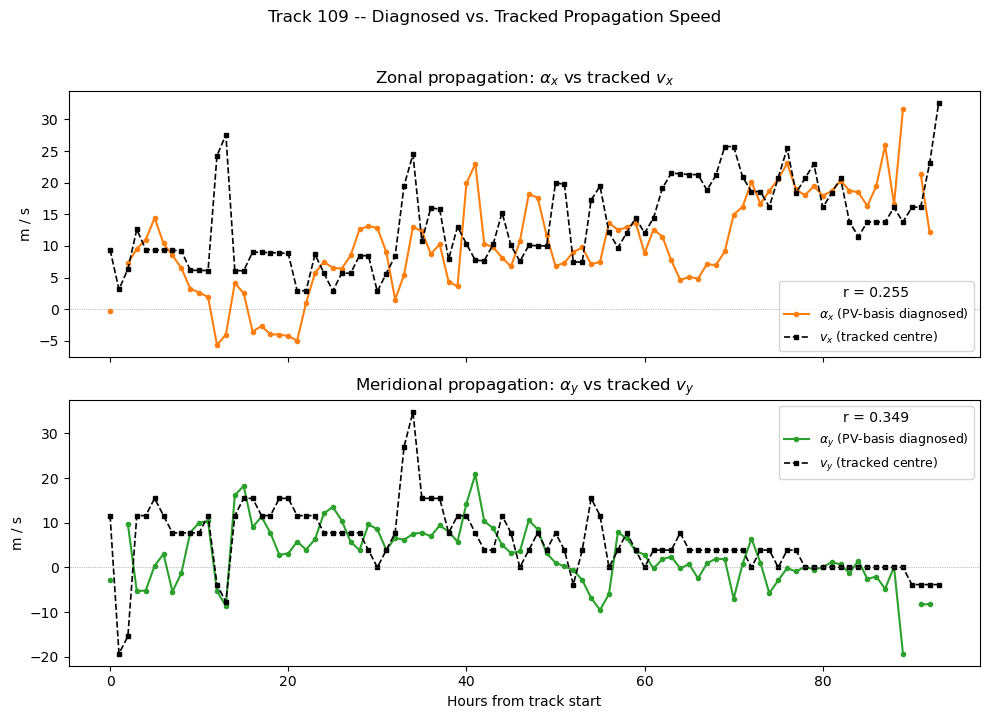

In [12]:
# 2-panel comparison: diagnosed propagation vs tracked speed
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

vx_sub = vx_track[1:-1]  # same indices as valid_idx
vy_sub = vy_track[1:-1]

# Zonal
ax1.plot(hours, coefs["ax"], "C1-o", ms=3, lw=1.5,
         label=r"$\alpha_x$ (PV-basis diagnosed)")
ax1.plot(hours, vx_sub, "k--s", ms=3, lw=1.2,
         label=r"$v_x$ (tracked centre)")
ax1.axhline(0, color="grey", lw=0.5, ls=":")
ax1.set_ylabel("m / s")
ax1.set_title(r"Zonal propagation: $\alpha_x$ vs tracked $v_x$")
valid_ax = np.isfinite(coefs["ax"]) & np.isfinite(vx_sub)
if valid_ax.sum() > 2:
    r_ax = np.corrcoef(coefs["ax"][valid_ax], vx_sub[valid_ax])[0, 1]
    ax1.legend(title=f"r = {r_ax:.3f}", fontsize=9)
else:
    ax1.legend(fontsize=9)

# Meridional
ax2.plot(hours, coefs["ay"], "C2-o", ms=3, lw=1.5,
         label=r"$\alpha_y$ (PV-basis diagnosed)")
ax2.plot(hours, vy_sub, "k--s", ms=3, lw=1.2,
         label=r"$v_y$ (tracked centre)")
ax2.axhline(0, color="grey", lw=0.5, ls=":")
ax2.set_xlabel("Hours from track start")
ax2.set_ylabel("m / s")
ax2.set_title(r"Meridional propagation: $\alpha_y$ vs tracked $v_y$")
valid_ay = np.isfinite(coefs["ay"]) & np.isfinite(vy_sub)
if valid_ay.sum() > 2:
    r_ay = np.corrcoef(coefs["ay"][valid_ay], vy_sub[valid_ay])[0, 1]
    ax2.legend(title=f"r = {r_ay:.3f}", fontsize=9)
else:
    ax2.legend(fontsize=9)

fig.suptitle("Track 109 -- Diagnosed vs. Tracked Propagation Speed", y=1.02)
fig.tight_layout()
plt.show()

## 7  Cartopy track comparison

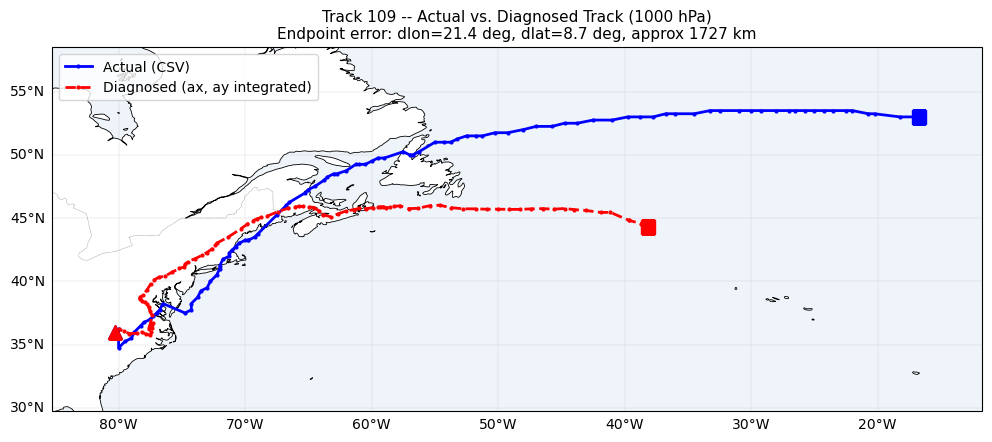

In [13]:
# Time-integrated diagnosed track vs actual CSV track
# ax, ay are instantaneous at the 15-min basis offset,
# applied over one full hour per timestep.

diag_lon = np.zeros(len(valid_idx) + 1)
diag_lat = np.zeros(len(valid_idx) + 1)
diag_lon[0] = lons_csv[valid_idx[0]]
diag_lat[0] = lats_csv[valid_idx[0]]

for i in range(len(valid_idx)):
    lat_r = np.radians(diag_lat[i])
    # ax [m/s] * 3600 s -> metres -> degrees lon
    dlon_deg = coefs["ax"][i] * 3600.0 / (R_EARTH * np.cos(lat_r)) * (180.0 / np.pi)
    # ay [m/s] * 3600 s -> metres -> degrees lat
    dlat_deg = coefs["ay"][i] * 3600.0 / R_EARTH * (180.0 / np.pi)

    if np.isfinite(dlon_deg) and np.isfinite(dlat_deg):
        diag_lon[i+1] = diag_lon[i] + dlon_deg
        diag_lat[i+1] = diag_lat[i] + dlat_deg
    else:
        diag_lon[i+1] = diag_lon[i]
        diag_lat[i+1] = diag_lat[i]

# Actual track (sub-range matching valid_idx)
actual_lon = lons_csv[valid_idx[0]:valid_idx[-1]+2]
actual_lat = lats_csv[valid_idx[0]:valid_idx[-1]+2]

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

lon_all = np.concatenate([actual_lon, diag_lon])
lat_all = np.concatenate([actual_lat, diag_lat])
pad = 5
ax.set_extent([lon_all.min()-pad, lon_all.max()+pad,
               lat_all.min()-pad, lat_all.max()+pad],
              crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
ax.add_feature(cfeature.OCEAN, alpha=0.15)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = gl.right_labels = False

# Actual track
ax.plot(actual_lon, actual_lat, "b-o", ms=2, lw=2.0, label="Actual (CSV)",
        transform=ccrs.PlateCarree(), zorder=5)
ax.plot(actual_lon[0], actual_lat[0], "b^", ms=10,
        transform=ccrs.PlateCarree(), zorder=6)
ax.plot(actual_lon[-1], actual_lat[-1], "bs", ms=10,
        transform=ccrs.PlateCarree(), zorder=6)

# Diagnosed track
ax.plot(diag_lon, diag_lat, "r--o", ms=2, lw=2.0,
        label="Diagnosed (ax, ay integrated)",
        transform=ccrs.PlateCarree(), zorder=5)
ax.plot(diag_lon[0], diag_lat[0], "r^", ms=10,
        transform=ccrs.PlateCarree(), zorder=6)
ax.plot(diag_lon[-1], diag_lat[-1], "rs", ms=10,
        transform=ccrs.PlateCarree(), zorder=6)

# Final displacement error
d_lon = actual_lon[-1] - diag_lon[-1]
d_lat = actual_lat[-1] - diag_lat[-1]
d_km = np.sqrt((d_lon * np.cos(np.radians(actual_lat[-1])) * 111.1)**2
               + (d_lat * 111.1)**2)
ax.set_title(f"Track 109 -- Actual vs. Diagnosed Track (1000 hPa)\n"
             f"Endpoint error: dlon={d_lon:.1f} deg, dlat={d_lat:.1f} deg, "
             f"approx {d_km:.0f} km", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
plt.show()

In [ ]:
# Animated GIF: PV tracking (cartopy) + basis decomposition
# Pre-load frame data for all valid timesteps
frames_data = {}

for count, ti in enumerate(valid_idx):
    t_i   = times[ti]
    ts_i  = pd.Timestamp(t_i)
    clat_i = lats_csv[ti]
    clon_i = lons_csv[ti]

    pv_0_2d, lat1d, lon1d = load_era5_field("pv", t_i)
    pv_m_2d, _, _ = load_era5_field("pv", t_i - np.timedelta64(1, "h"))
    pv_p_2d, _, _ = load_era5_field("pv", t_i + np.timedelta64(1, "h"))

    pv_bar_0 = load_clim_field("pv", ts_i.month, ts_i.day, ts_i.hour)

    # All patches centred on t's tracked position (dh = 0)
    pv_0_pa, xr_, yr_, lat_s, lon_s = extract_patch(pv_0_2d, lat1d, lon1d, clat_i, clon_i)
    pv_m_pa, _, _, _, _ = extract_patch(pv_m_2d, lat1d, lon1d, clat_i, clon_i)
    pv_p_pa, _, _, _, _ = extract_patch(pv_p_2d, lat1d, lon1d, clat_i, clon_i)
    bar_0_pa, *_ = extract_patch(pv_bar_0, lat1d, lon1d, clat_i, clon_i)

    anom_0 = pv_0_pa - bar_0_pa

    dx_0, dy_0 = compute_gradients(anom_0, lat_s, xr_, yr_)

    b = compute_orthogonal_basis(
        anom_0, dx_0, dy_0,
        xr_, yr_, mask=MASK_SPEC,
        apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG,
    )

    # Skip frames with degenerate basis
    _MIN_NORM = 1e-6
    if b.norms is None or any(b.norms[k] < _MIN_NORM for k in ["beta","ax","ay","gamma1","gamma2","sigma"]):
        continue
    pv_stack = np.stack([pv_m_pa, pv_0_pa, pv_p_pa], axis=0)
    dt_raw = ddt(pv_stack, dt_s=3600.0)[1]
    dt_sm = gaussian_smooth_nan(dt_raw, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG)
    p = project_field(dt_sm, b)

    frames_data[count] = {
        "pv_total": pv_0_pa,
        "pv_anom": anom_0,
        "center_lat": clat_i,
        "center_lon": clon_i,
        "lat_vec": lat_s,
        "lon_vec": lon_s,
        "basis": b,
        "proj": p,
        "x_rel": xr_,
        "y_rel": yr_,
    }

frame_ids = sorted(frames_data.keys())
gif_frames = frame_ids
print(f"Loaded {len(frame_ids)} frames for hourly GIF ({len(valid_idx) - len(frame_ids)} skipped)")

# Precompute colour limits
all_pv = np.concatenate([frames_data[f]["pv_total"].ravel() for f in gif_frames])
pv_vmin, pv_vmax = np.nanpercentile(all_pv, [2, 98])

coef_keys = ["beta", "ax", "ay", "gamma1", "gamma2", "sigma"]
field_signs = [1.0, -1.0, -1.0, -1.0, -1.0, 1.0]

coef_labels_units = [
    r"$\beta$ [s$^{-1}$]",
    r"$\alpha_x$ [m s$^{-1}$]",
    r"$\alpha_y$ [m s$^{-1}$]",
    r"$\gamma_1$ [m$^2$ s$^{-1}$]",
    r"$\gamma_2$ [m$^2$ s$^{-1}$]",
    r"$\sigma$ [m$^2$ s$^{-1}$]",
]
coef_colors = ["C0", "C1", "C2", "C3", "C4", "C5"]
phi_names = ["phi_int", "phi_dx", "phi_dy", "phi_def", "phi_strain", "phi_lap"]
phi_labels = [r"$\beta \cdot \hat\Phi_1$",
              r"$-\alpha_x \cdot \hat\Phi_2$",
              r"$-\alpha_y \cdot \hat\Phi_3$",
              r"$-\gamma_1 \cdot \hat\Phi_4$",
              r"$-\gamma_2 \cdot \hat\Phi_5$",
              r"$\sigma \cdot \hat\Phi_6$"]

basis_vmax = {}
for ck, pn, sgn in zip(coef_keys, phi_names, field_signs):
    vals = []
    for f in gif_frames:
        fd = frames_data[f]
        phi = getattr(fd["basis"], pn)
        c = fd["proj"][ck]
        if np.isfinite(c) and phi is not None:
            fld = sgn * c * phi
            vals.append(np.nanmax(np.abs(fld[fd["basis"].mask])))
    basis_vmax[ck] = np.nanpercentile(vals, 95) if vals else 1.0

# Central projection centred on mid-track
mid_f = gif_frames[len(gif_frames) // 2]
proj_map = ccrs.LambertConformal(
    central_longitude=frames_data[mid_f]["center_lon"],
    central_latitude=frames_data[mid_f]["center_lat"],
)
data_crs = ccrs.PlateCarree()

# Build figure layout
fig = plt.figure(figsize=(22, 16))
fig.subplots_adjust(left=0.04, right=0.98)
outer = gridspec.GridSpec(1, 2, width_ratios=[1.4, 1], wspace=0.18)

ax_pv = fig.add_subplot(outer[0], projection=proj_map)

inner = gridspec.GridSpecFromSubplotSpec(6, 2, subplot_spec=outer[1],
                                          hspace=0.45, wspace=0.35)
ax_1d = [fig.add_subplot(inner[i, 0]) for i in range(6)]
ax_2d = [fig.add_subplot(inner[i, 1]) for i in range(6)]

def draw_pv_map(ax_map, fidx, frame_pos):
    fd = frames_data[fidx]
    lon2d, lat2d = np.meshgrid(fd["lon_vec"], fd["lat_vec"])

    ax_map.set_extent([fd["lon_vec"].min()-5, fd["lon_vec"].max()+5,
                       fd["lat_vec"].min()-5, fd["lat_vec"].max()+5],
                      crs=data_crs)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax_map.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5,
                     x_inline=False, y_inline=False)

    cf = ax_map.contourf(lon2d, lat2d, fd["pv_total"], levels=30,
                          cmap="YlGnBu", vmin=pv_vmin, vmax=pv_vmax,
                          transform=data_crs)

    # basis.mask contour on cartopy map
    ax_map.contour(lon2d, lat2d, fd["basis"].mask.astype(float),
                   levels=[0.5], colors="k", linewidths=1.5, linestyles="-",
                   transform=data_crs)

    # Past track trajectory
    past = [f for f in gif_frames[:frame_pos + 1]]
    if past:
        tl = [frames_data[f]["center_lon"] for f in past]
        tt = [frames_data[f]["center_lat"] for f in past]
        ax_map.plot(tl, tt, "r-", lw=2, transform=data_crs, zorder=5)
        ax_map.plot(tl[-1], tt[-1], "ro", ms=8, transform=data_crs, zorder=6)
        if len(tl) > 1:
            ax_map.plot(tl[0], tt[0], "r^", ms=7, transform=data_crs, zorder=6)

    ti_actual = valid_idx[fidx]
    ax_map.set_title(f"PV @ 1000 hPa  |  {pd.Timestamp(times[ti_actual])}", fontsize=11)
    return cf

def draw_2d_panels(fidx):
    fd = frames_data[fidx]
    Xr_f, Yr_f = np.meshgrid(fd["x_rel"], fd["y_rel"])
    for i, (ck, pn, lab, sgn) in enumerate(zip(coef_keys, phi_names, phi_labels, field_signs)):
        ax_2d[i].cla()
        phi = getattr(fd["basis"], pn)
        c = fd["proj"][ck] if np.isfinite(fd["proj"][ck]) else 0.0
        fld = sgn * c * phi
        vm = basis_vmax[ck]
        ax_2d[i].pcolormesh(Xr_f, Yr_f, fld, cmap="RdBu_r",
                             vmin=-vm, vmax=vm, shading="auto")
        # basis.mask contour
        ax_2d[i].contour(Xr_f, Yr_f, fd["basis"].mask.astype(float),
                         levels=[0.5], colors="k", linewidths=1.8,
                         linestyles="-", alpha=0.45)
        ax_2d[i].set_aspect("equal")
        ax_2d[i].set_title(lab, fontsize=9)
        if i == 3:
            ax_2d[i].set_xlabel("Δlon (deg)")

# Draw first frame
f0 = gif_frames[0]
fd0 = frames_data[f0]
cf_pv = draw_pv_map(ax_pv, f0, 0)
cb_pv = fig.colorbar(cf_pv, ax=ax_pv, label="PV (PVU)", shrink=0.75, pad=0.02)

# 1D curves over full lifecycle
markers_1d = []
life_hours = np.arange(len(valid_idx))
for i, (ck, lab_u, col) in enumerate(zip(coef_keys, coef_labels_units, coef_colors)):
    ax_1d[i].plot(life_hours, coefs[ck], color=col, lw=1.5)
    ax_1d[i].axhline(0, color="grey", lw=0.4, ls=":")
    m, = ax_1d[i].plot(f0, coefs[ck][f0], "o", color=col, ms=8, zorder=5)
    markers_1d.append(m)
    ax_1d[i].set_ylabel(lab_u, fontsize=9)
    if i == 3:
        ax_1d[i].set_xlabel("Hours from track start")

draw_2d_panels(f0)

fig.suptitle("Track 109 (cyclone) — PV lifecycle + basis decomposition (1000 hPa)",
             fontsize=13, y=0.98)

def update(frame_pos):
    fidx = gif_frames[frame_pos]
    fd = frames_data[fidx]

    ax_pv.cla()
    draw_pv_map(ax_pv, fidx, frame_pos)

    for i, ck in enumerate(coef_keys):
        markers_1d[i].set_data([fidx], [coefs[ck][fidx]])

    draw_2d_panels(fidx)
    return []

anim = FuncAnimation(fig, update, frames=len(gif_frames),
                      interval=200, blit=False)
anim.save(GIF_PATH, writer=PillowWriter(fps=5))
plt.close(fig)

print(f"Saved GIF → {GIF_PATH}")
IPImage(filename=GIF_PATH)


## 8  Budget closure — RHS term coefficients

In [ ]:
# Budget closure requires U, V, W fields at 1000 hPa
import os
u_file = f"{ERA_DIR}/era5_u_1990_10.nc"
v_file = f"{ERA_DIR}/era5_v_1990_10.nc"
w_file = f"{ERA_DIR}/era5_w_1990_10.nc"

if not (os.path.exists(u_file) and os.path.exists(v_file) and os.path.exists(w_file)):
    print("ERA5 U/V/W files not found — skipping budget closure.")
    budget_ok = False
else:
    budget_ok = True

    # ── Vertical stencil for ddp (consistent with tendency.py) ──
    # Pick a 3-level window around LEVEL_PA from DEFAULT_LEVELS.
    # At a boundary level (e.g. 1000 hPa = max) ddp uses one-sided;
    # at an interior level (e.g. 850 hPa) it uses 3-point Lagrange.
    _sorted = sorted(DEFAULT_LEVELS)          # ascending hPa
    _ki     = _sorted.index(int(LEVEL_PA))
    _lo     = max(0, _ki - 1)
    _hi     = min(len(_sorted) - 1, _ki + 1)
    DDP_LEVS   = _sorted[_lo : _hi + 1]               # 2 or 3 levels (hPa)
    DDP_PA     = np.array(DDP_LEVS, dtype=float) * 100.0  # → Pa
    TARGET_K   = DDP_LEVS.index(int(LEVEL_PA))         # slice index
    print(f"Vertical stencil: {DDP_LEVS} hPa  (target idx {TARGET_K})")

    TERM_NAMES_C = [
        "dq/dt",
        r"$-\bar{u}\,q'_x$",
        r"$-\bar{v}\,q'_y$",
        r"$-u'\,\bar{q}_x$",
        r"$-v'\,\bar{q}_y$",
        r"$-\bar{w}\,q'_p$",
        r"$-w'\,\bar{q}_p$",
        r"$\Sigma$",
    ]
    term_coefs_c = {name: {k: [] for k in ["beta","ax","ay","gamma1","gamma2","sigma"]}
                    for name in TERM_NAMES_C}

    smooth_fn = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG,
                                               grid_spacing=GRID_DEG)
    n_skipped_b = 0

    for count, ti in enumerate(valid_idx):
        t_i   = times[ti]
        ts_i  = pd.Timestamp(t_i)
        clat_i = lats_csv[ti]
        clon_i = lons_csv[ti]

        # PV fields at LEVEL_PA
        pv_0_2d, lat1d, lon1d = load_era5_field("pv", t_i)
        pv_m_2d, _, _         = load_era5_field("pv", t_i - np.timedelta64(1, "h"))
        pv_p_2d, _, _         = load_era5_field("pv", t_i + np.timedelta64(1, "h"))

        pv_bar_0 = load_clim_field("pv", ts_i.month, ts_i.day, ts_i.hour)


        # U, V, W at t (LEVEL_PA only)
        u_2d, _, _ = load_era5_field("u", t_i)
        v_2d, _, _ = load_era5_field("v", t_i)
        w_2d, _, _ = load_era5_field("w", t_i)
        u_bar = load_clim_field("u", ts_i.month, ts_i.day, ts_i.hour)
        v_bar = load_clim_field("v", ts_i.month, ts_i.day, ts_i.hour)
        w_bar = load_clim_field("w", ts_i.month, ts_i.day, ts_i.hour)

        # PV at stencil levels for ddp (total + clim)
        pv_lev, bar_lev = [], []
        for lev_hpa in DDP_LEVS:
            pv_l, _, _ = load_era5_field("pv", t_i, level_hpa=lev_hpa)
            bar_l = load_clim_field("pv", ts_i.month, ts_i.day, ts_i.hour,
                                    level_hpa=lev_hpa)
            pv_l_pa, *_ = extract_patch(pv_l, lat1d, lon1d, clat_i, clon_i)
            bar_l_pa, *_ = extract_patch(bar_l, lat1d, lon1d, clat_i, clon_i)
            pv_lev.append(pv_l_pa)
            bar_lev.append(bar_l_pa)

        pv_3d  = np.stack(pv_lev,  axis=0)   # (nlev, nlat, nlon)
        bar_3d = np.stack(bar_lev, axis=0)
        anom_3d = pv_3d - bar_3d

        # ddp: 3-point Lagrange interior / one-sided at boundary (Pa units)
        anom_dp = ddp(anom_3d, DDP_PA)[TARGET_K]   # dq'/dp  [PVU/Pa]
        bar_dp  = ddp(bar_3d,  DDP_PA)[TARGET_K]   # dq̄/dp   [PVU/Pa]

        # Horizontal patches at LEVEL_PA
        pv_0_pa, xr_, yr_, lat_s, lon_s = extract_patch(pv_0_2d, lat1d, lon1d, clat_i, clon_i)
        pv_m_pa, _, _, _, _ = extract_patch(pv_m_2d, lat1d, lon1d, clat_i, clon_i)
        pv_p_pa, _, _, _, _ = extract_patch(pv_p_2d, lat1d, lon1d, clat_i, clon_i)
        bar_0_pa, *_ = extract_patch(pv_bar_0, lat1d, lon1d, clat_i, clon_i)

        u_pa, *_    = extract_patch(u_2d,   lat1d, lon1d, clat_i, clon_i)
        v_pa, *_    = extract_patch(v_2d,   lat1d, lon1d, clat_i, clon_i)
        w_pa, *_    = extract_patch(w_2d,   lat1d, lon1d, clat_i, clon_i)
        ub_pa, *_   = extract_patch(u_bar,  lat1d, lon1d, clat_i, clon_i)
        vb_pa, *_   = extract_patch(v_bar,  lat1d, lon1d, clat_i, clon_i)
        wb_pa, *_   = extract_patch(w_bar,  lat1d, lon1d, clat_i, clon_i)

        anom_0 = pv_0_pa - bar_0_pa
        u_anom = u_pa - ub_pa
        v_anom = v_pa - vb_pa
        w_anom = w_pa - wb_pa

        # Horizontal gradients (same as compute_gradients helper)
        dx_0, dy_0 = compute_gradients(anom_0, lat_s, xr_, yr_)
        bar_dx, bar_dy = compute_gradients(bar_0_pa, lat_s, xr_, yr_)

        # Tendency
        pv_stack = np.stack([pv_m_pa, pv_0_pa, pv_p_pa], axis=0)
        dt_raw = ddt(pv_stack, dt_s=3600.0)[1]

        # Basis from dh = 0 fields
        b = compute_orthogonal_basis(
            anom_0, dx_0, dy_0, xr_, yr_,
            mask=MASK_SPEC, apply_smoothing=True,
            smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_DEG,
        )

        # ── Guard: skip if Gram-Schmidt produced degenerate basis ──
        _MIN_NORM = 1e-6
        if b.norms is None or any(b.norms[k] < _MIN_NORM for k in ["beta","ax","ay","gamma1","gamma2","sigma"]):
            for name in TERM_NAMES_C:
                for k in ["beta","ax","ay","gamma1","gamma2","sigma"]:
                    term_coefs_c[name][k].append(np.nan)
            n_skipped_b += 1
            continue

        def proj_term(field_2d):
            return project_field(smooth_fn(field_2d), b)

        # dq/dt
        p = proj_term(dt_raw)
        for k in ["beta","ax","ay","gamma1","gamma2","sigma"]:
            term_coefs_c["dq/dt"][k].append(p[k])

        # Individual RHS advection terms (horizontal + vertical)
        # w is omega [Pa/s], anom_dp / bar_dp are [PVU/Pa] → product is [PVU/s]
        rhs = [
            (r"$-\bar{u}\,q'_x$",  (-ub_pa * dx_0)),
            (r"$-\bar{v}\,q'_y$",  (-vb_pa * dy_0)),
            (r"$-u'\,\bar{q}_x$",  (-u_anom * bar_dx)),
            (r"$-v'\,\bar{q}_y$",  (-v_anom * bar_dy)),
            (r"$-\bar{w}\,q'_p$",  (-wb_pa * anom_dp)),
            (r"$-w'\,\bar{q}_p$",  (-w_anom * bar_dp)),
        ]
        closure = np.zeros_like(pv_0_pa)
        for name, fld in rhs:
            p = proj_term(fld)
            for k in ["beta","ax","ay","gamma1","gamma2","sigma"]:
                term_coefs_c[name][k].append(p[k])
            closure += fld

        p = proj_term(closure)
        for k in ["beta","ax","ay","gamma1","gamma2","sigma"]:
            term_coefs_c[r"$\Sigma$"][k].append(p[k])

        if count % 20 == 0:
            print(f"  Budget [{count+1}/{len(valid_idx)}]")

    # Convert to arrays
    for name in TERM_NAMES_C:
        for k in term_coefs_c[name]:
            term_coefs_c[name][k] = np.array(term_coefs_c[name][k])

    print(f"Budget projection done — {n_skipped_b} skipped (degenerate basis).")


In [ ]:
# 4-panel budget decomposition curves
if budget_ok:
    fig = plt.figure(figsize=(22, 14))
    gs = fig.add_gridspec(3, 3, width_ratios=[1, 1, 0.35], wspace=0.35, hspace=0.3)

    ax_panels = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[2, 0]),,
        fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 1]),,
    ]
    ax_legend = fig.add_subplot(gs[:, 2])
    ax_legend.axis("off")

    coef_info = [
        ("beta",  r"$\beta$ (intensification)",     r"s$^{-1}$"),
        ("ax",    r"$\alpha_x$ (zonal propagation)", "m/s"),
        ("ay",    r"$\alpha_y$ (merid. propagation)","m/s"),
        ("gamma1", r"$\gamma_1$ (shear def.)",       r"m$^2$ s$^{-1}$"),
    ("gamma2", r"$\gamma_2$ (strain def.)",      r"m$^2$ s$^{-1}$"),
    ("sigma",  r"$\sigma$ (Laplacian)",          r"m$^2$ s$^{-1}$"),
    ]

    tab_colors = plt.cm.tab10(np.linspace(0, 1, 10))
    term_style_c = {
        "dq/dt":                  dict(color="k",           lw=2.5, ls="-",  zorder=10),
        r"$\Sigma$":              dict(color="k",           lw=2.0, ls="--", zorder=9),
        r"$-\bar{u}\,q'_x$":     dict(color=tab_colors[0], lw=1.5, ls="-"),
        r"$-\bar{v}\,q'_y$":     dict(color=tab_colors[1], lw=1.5, ls="-"),
        r"$-u'\,\bar{q}_x$":     dict(color=tab_colors[2], lw=1.5, ls="-"),
        r"$-v'\,\bar{q}_y$":     dict(color=tab_colors[3], lw=1.5, ls="-"),
        r"$-\bar{w}\,q'_p$":     dict(color=tab_colors[4], lw=1.5, ls="-"),
        r"$-w'\,\bar{q}_p$":     dict(color=tab_colors[5], lw=1.5, ls="-"),
    }

    dh_arr = np.arange(len(valid_idx))
    handles_all = []
    for ax, (key, title, unit) in zip(ax_panels, coef_info):
        for name in TERM_NAMES_C:
            st = term_style_c[name]
            h, = ax.plot(dh_arr, term_coefs_c[name][key], label=name, **st)
            if ax is ax_panels[0]:
                handles_all.append(h)
        ax.axhline(0, color="gray", lw=0.5, ls=":")
        ax.set_title(title)
        ax.set_ylabel(unit)

    ax_panels[4].set_xlabel("Hours from track start")
    ax_panels[5].set_xlabel("Hours from track start")

    ax_legend.legend(handles_all, TERM_NAMES_C, loc="center", fontsize=10,
                     frameon=True, framealpha=0.9, edgecolor="gray")

    fig.suptitle("Track 109 -- Budget decomposition (1000 hPa, horizontal + vertical advection)", y=1.02)
    plt.show()
else:
    print("Budget closure was skipped (U/V data not available).")

## Summary

- **`compute_orthogonal_basis`** builds the six Gram-Schmidt-orthogonalised
  basis fields (Φ₁…Φ₆) from the PV anomaly and its spatial gradients.
- **`project_field`** decomposes any 2-D field (e.g. dq/dt) into
  intensification (β), propagation (αx, αy), shear (γ₁), strain (γ₂), and Laplacian (σ) coefficients.
- Uses `mask="> 0"` to directly isolate the cyclone's *positive*
  PV anomaly without any sign flip.
- Basis is built from **dh = 0 fields only** (no temporal interpolation).
- Symmetric ±15-grid (±22.5°) patch at 1.5° ERA5 resolution.

- The **Cartopy track comparison** shows actual CSV positions vs. the track
  obtained by time-integrating (αx, αy) × 1 h per step.
- Budget closure decomposes propagation drivers into mean-wind advection
  of the anomaly vs. anomaly advection of the mean PV gradient.
